In [450]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt


In [451]:
data = yf.download("AAPL", period="730d", interval="4h")
data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Datetime,,,,,
2022-05-31 13:30:00+00:00,149.559998,150.660004,146.839996,150.000000,51946593
2022-05-31 17:30:00+00:00,148.750000,150.509995,148.729996,149.550003,24986054
2022-06-01 13:30:00+00:00,148.332199,151.740005,147.679993,149.899994,45588914
2022-06-01 17:30:00+00:00,148.699997,149.990005,148.009995,148.350006,22678330
2022-06-02 13:30:00+00:00,150.179092,150.690002,146.860001,147.830002,45118395


In [452]:
data["FutureClose"] = data["Close"].shift(-1)

data.head()

Price,Close,High,Low,Open,Volume,FutureClose
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,
Datetime,,,,,,
2022-05-31 13:30:00+00:00,149.559998,150.660004,146.839996,150.000000,51946593,148.750000
2022-05-31 17:30:00+00:00,148.750000,150.509995,148.729996,149.550003,24986054,148.332199
2022-06-01 13:30:00+00:00,148.332199,151.740005,147.679993,149.899994,45588914,148.699997
2022-06-01 17:30:00+00:00,148.699997,149.990005,148.009995,148.350006,22678330,150.179092
2022-06-02 13:30:00+00:00,150.179092,150.690002,146.860001,147.830002,45118395,151.229996


In [453]:
data["PctChange"] = (data["FutureClose"].squeeze() - data["Close"].squeeze()) / data["Close"].squeeze()

data.head()

Price,Close,High,Low,Open,Volume,FutureClose,PctChange
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,
Datetime,,,,,,,
2022-05-31 13:30:00+00:00,149.559998,150.660004,146.839996,150.000000,51946593,148.750000,-0.005416
2022-05-31 17:30:00+00:00,148.750000,150.509995,148.729996,149.550003,24986054,148.332199,-0.002809
2022-06-01 13:30:00+00:00,148.332199,151.740005,147.679993,149.899994,45588914,148.699997,0.002480
2022-06-01 17:30:00+00:00,148.699997,149.990005,148.009995,148.350006,22678330,150.179092,0.009947
2022-06-02 13:30:00+00:00,150.179092,150.690002,146.860001,147.830002,45118395,151.229996,0.006998


In [454]:
data.dropna(inplace=True)

data.head()

Price,Close,High,Low,Open,Volume,FutureClose,PctChange
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,
Datetime,,,,,,,
2022-05-31 13:30:00+00:00,149.559998,150.660004,146.839996,150.000000,51946593,148.750000,-0.005416
2022-05-31 17:30:00+00:00,148.750000,150.509995,148.729996,149.550003,24986054,148.332199,-0.002809
2022-06-01 13:30:00+00:00,148.332199,151.740005,147.679993,149.899994,45588914,148.699997,0.002480
2022-06-01 17:30:00+00:00,148.699997,149.990005,148.009995,148.350006,22678330,150.179092,0.009947
2022-06-02 13:30:00+00:00,150.179092,150.690002,146.860001,147.830002,45118395,151.229996,0.006998


In [455]:
data["MA5"] = data["Close"].rolling(window=5).mean()
data["MA10"] = data["Close"].rolling(window=10).mean()
data["MA20"] = data["Close"].rolling(window=20).mean()

data.head()

Price,Close,High,Low,Open,Volume,FutureClose,PctChange,MA5,MA10,MA20
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,,,
Datetime,,,,,,,,,,
2022-05-31 13:30:00+00:00,149.559998,150.660004,146.839996,150.000000,51946593,148.750000,-0.005416,NaN,NaN,NaN
2022-05-31 17:30:00+00:00,148.750000,150.509995,148.729996,149.550003,24986054,148.332199,-0.002809,NaN,NaN,NaN
2022-06-01 13:30:00+00:00,148.332199,151.740005,147.679993,149.899994,45588914,148.699997,0.002480,NaN,NaN,NaN
2022-06-01 17:30:00+00:00,148.699997,149.990005,148.009995,148.350006,22678330,150.179092,0.009947,NaN,NaN,NaN
2022-06-02 13:30:00+00:00,150.179092,150.690002,146.860001,147.830002,45118395,151.229996,0.006998,149.104257,NaN,NaN


In [456]:
delta = data["Close"].diff()

up = delta.clip(lower=0)
down = -1 * delta.clip(upper=0)

avg_gain = up.rolling(window=14).mean()
avg_loss = down.rolling(window=14).mean()

rs = avg_gain / avg_loss

data["RSI14"] = 100 - (100 / (rs + 1))

data.head()

Price,Close,High,Low,Open,Volume,FutureClose,PctChange,MA5,MA10,MA20,RSI14
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,,,,
Datetime,,,,,,,,,,,
2022-05-31 13:30:00+00:00,149.559998,150.660004,146.839996,150.000000,51946593,148.750000,-0.005416,NaN,NaN,NaN,NaN
2022-05-31 17:30:00+00:00,148.750000,150.509995,148.729996,149.550003,24986054,148.332199,-0.002809,NaN,NaN,NaN,NaN
2022-06-01 13:30:00+00:00,148.332199,151.740005,147.679993,149.899994,45588914,148.699997,0.002480,NaN,NaN,NaN,NaN
2022-06-01 17:30:00+00:00,148.699997,149.990005,148.009995,148.350006,22678330,150.179092,0.009947,NaN,NaN,NaN,NaN
2022-06-02 13:30:00+00:00,150.179092,150.690002,146.860001,147.830002,45118395,151.229996,0.006998,149.104257,NaN,NaN,NaN


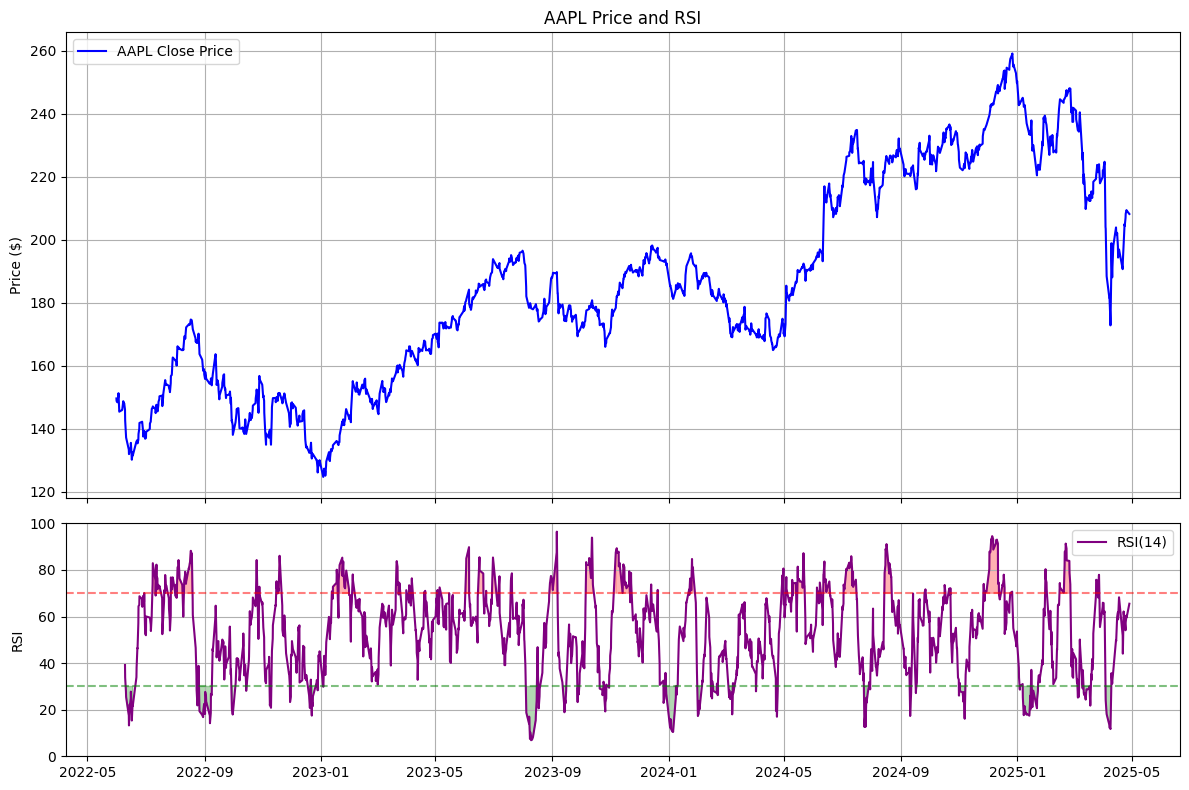

In [457]:
# Create a figure with two subplots (price and RSI)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

# Plot the closing price on the top subplot
ax1.plot(data.index, data['Close'], label='AAPL Close Price', color='blue')
ax1.set_title('AAPL Price and RSI')
ax1.set_ylabel('Price ($)')
ax1.grid(True)
ax1.legend()

# Plot the RSI on the bottom subplot
ax2.plot(data.index, data['RSI14'], label='RSI(14)', color='purple')
ax2.axhline(y=70, color='r', linestyle='--', alpha=0.5)  # Overbought line
ax2.axhline(y=30, color='g', linestyle='--', alpha=0.5)  # Oversold line
ax2.fill_between(data.index, data['RSI14'], 70, where=(data['RSI14'] >= 70), color='red', alpha=0.3)  # Overbought areas
ax2.fill_between(data.index, data['RSI14'], 30, where=(data['RSI14'] <= 30), color='green', alpha=0.3)  # Oversold areas
ax2.set_ylabel('RSI')
ax2.set_ylim(0, 100)
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

In [458]:
data["SD5"] = data["Close"].rolling(window=5).std()
data["SD10"] = data["Close"].rolling(window=10).std()

data.head()

Price,Close,High,Low,Open,Volume,FutureClose,PctChange,MA5,MA10,MA20,RSI14,SD5,SD10
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,,,,,,
Datetime,,,,,,,,,,,,,
2022-05-31 13:30:00+00:00,149.559998,150.660004,146.839996,150.000000,51946593,148.750000,-0.005416,NaN,NaN,NaN,NaN,NaN,NaN
2022-05-31 17:30:00+00:00,148.750000,150.509995,148.729996,149.550003,24986054,148.332199,-0.002809,NaN,NaN,NaN,NaN,NaN,NaN
2022-06-01 13:30:00+00:00,148.332199,151.740005,147.679993,149.899994,45588914,148.699997,0.002480,NaN,NaN,NaN,NaN,NaN,NaN
2022-06-01 17:30:00+00:00,148.699997,149.990005,148.009995,148.350006,22678330,150.179092,0.009947,NaN,NaN,NaN,NaN,NaN,NaN
2022-06-02 13:30:00+00:00,150.179092,150.690002,146.860001,147.830002,45118395,151.229996,0.006998,149.104257,NaN,NaN,NaN,0.749661,NaN


In [459]:
data["ROC5"] = data["Close"].pct_change(periods=5)
data["ROC10"] = data["Close"].pct_change(periods=10)
data["ROC20"] = data["Close"].pct_change(periods=20)

data.head()

Price,Close,High,Low,Open,Volume,FutureClose,PctChange,MA5,MA10,MA20,RSI14,SD5,SD10,ROC5,ROC10,ROC20
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,,,,,,,,,
Datetime,,,,,,,,,,,,,,,,
2022-05-31 13:30:00+00:00,149.559998,150.660004,146.839996,150.000000,51946593,148.750000,-0.005416,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-05-31 17:30:00+00:00,148.750000,150.509995,148.729996,149.550003,24986054,148.332199,-0.002809,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-06-01 13:30:00+00:00,148.332199,151.740005,147.679993,149.899994,45588914,148.699997,0.002480,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-06-01 17:30:00+00:00,148.699997,149.990005,148.009995,148.350006,22678330,150.179092,0.009947,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-06-02 13:30:00+00:00,150.179092,150.690002,146.860001,147.830002,45118395,151.229996,0.006998,149.104257,NaN,NaN,NaN,0.749661,NaN,NaN,NaN,NaN


In [460]:
data["HighLow"] = data["High"] - data["Low"]
data["HighClose"] = (data["High"] - data["Close"].shift()).abs()
data["LowClose"] = (data["Low"] - data["Close"].shift()).abs()

data["TR"] = data[["HighLow", "HighClose", "LowClose"]].max(axis=1)

data["ATR14"] = data["TR"].rolling(window=14).mean()

data.drop(columns=["HighLow", "HighClose", "LowClose", "TR"], inplace=True)

data.head()

Price,Close,High,Low,Open,Volume,FutureClose,PctChange,MA5,MA10,MA20,RSI14,SD5,SD10,ROC5,ROC10,ROC20,ATR14
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,,,,,,,,,,
Datetime,,,,,,,,,,,,,,,,,
2022-05-31 13:30:00+00:00,149.559998,150.660004,146.839996,150.000000,51946593,148.750000,-0.005416,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-05-31 17:30:00+00:00,148.750000,150.509995,148.729996,149.550003,24986054,148.332199,-0.002809,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-06-01 13:30:00+00:00,148.332199,151.740005,147.679993,149.899994,45588914,148.699997,0.002480,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-06-01 17:30:00+00:00,148.699997,149.990005,148.009995,148.350006,22678330,150.179092,0.009947,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-06-02 13:30:00+00:00,150.179092,150.690002,146.860001,147.830002,45118395,151.229996,0.006998,149.104257,NaN,NaN,NaN,0.749661,NaN,NaN,NaN,NaN,NaN


In [461]:
data["VOLMA10"] = data["Volume"].rolling(window=10).mean()

data.head()

Price,Close,High,Low,Open,Volume,FutureClose,PctChange,MA5,MA10,MA20,RSI14,SD5,SD10,ROC5,ROC10,ROC20,ATR14,VOLMA10
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,,,,,,,,,,,
Datetime,,,,,,,,,,,,,,,,,,
2022-05-31 13:30:00+00:00,149.559998,150.660004,146.839996,150.000000,51946593,148.750000,-0.005416,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-05-31 17:30:00+00:00,148.750000,150.509995,148.729996,149.550003,24986054,148.332199,-0.002809,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-06-01 13:30:00+00:00,148.332199,151.740005,147.679993,149.899994,45588914,148.699997,0.002480,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-06-01 17:30:00+00:00,148.699997,149.990005,148.009995,148.350006,22678330,150.179092,0.009947,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-06-02 13:30:00+00:00,150.179092,150.690002,146.860001,147.830002,45118395,151.229996,0.006998,149.104257,NaN,NaN,NaN,0.749661,NaN,NaN,NaN,NaN,NaN,NaN


In [462]:
data.isna().sum()

Price        Ticker
Close        AAPL       0
High         AAPL       0
Low          AAPL       0
Open         AAPL       0
Volume       AAPL       0
FutureClose             0
PctChange               0
MA5                     4
MA10                    9
MA20                   19
RSI14                  14
SD5                     4
SD10                    9
ROC5                    5
ROC10                  10
ROC20                  20
ATR14                  13
VOLMA10                 9
dtype: int64

In [463]:
def add_bollinger_bands(df: pd.DataFrame, window=20, no_std=2):
  rolling_mean = df["Close"].rolling(window=window).mean()
  rolling_std = df["Close"].rolling(window=window).std()

  df["BollMid"] = rolling_mean
  df["BollUpper"] = rolling_mean + (no_std * rolling_std)
  df["BollLower"] = rolling_mean - (no_std * rolling_std)

  df["BollBandwidth"] = df["BollUpper"] - df["BollLower"]

  return df

data = add_bollinger_bands(data)

data.head()

Price,Close,High,Low,Open,Volume,FutureClose,PctChange,MA5,MA10,MA20,...,SD10,ROC5,ROC10,ROC20,ATR14,VOLMA10,BollMid,BollUpper,BollLower,BollBandwidth
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,,,,...,,,,,,,,,,
Datetime,,,,,,,,,,,,,,,,,,,,,
2022-05-31 13:30:00+00:00,149.559998,150.660004,146.839996,150.000000,51946593,148.750000,-0.005416,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-05-31 17:30:00+00:00,148.750000,150.509995,148.729996,149.550003,24986054,148.332199,-0.002809,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-06-01 13:30:00+00:00,148.332199,151.740005,147.679993,149.899994,45588914,148.699997,0.002480,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-06-01 17:30:00+00:00,148.699997,149.990005,148.009995,148.350006,22678330,150.179092,0.009947,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-06-02 13:30:00+00:00,150.179092,150.690002,146.860001,147.830002,45118395,151.229996,0.006998,149.104257,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


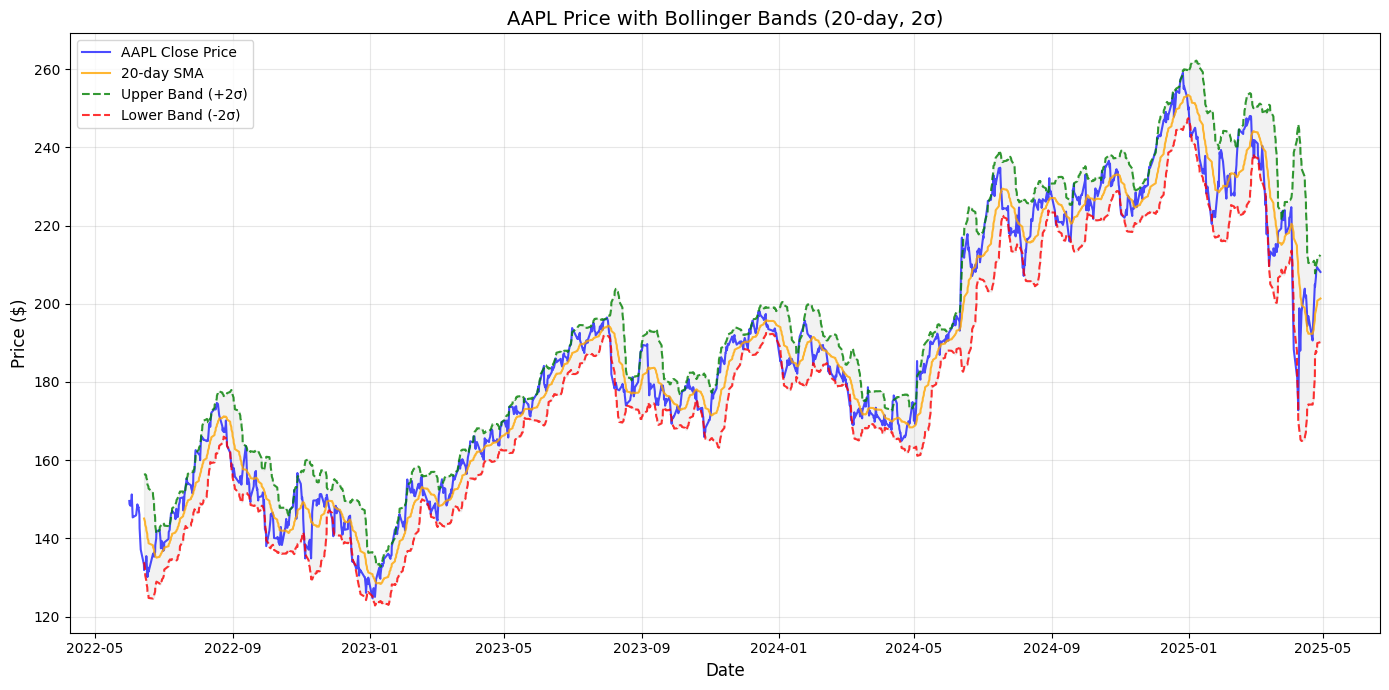

In [464]:
# Create a figure
plt.figure(figsize=(14, 7))

# Plot the closing price
plt.plot(data.index, data['Close'], label='AAPL Close Price', color='blue', alpha=0.7)

# Plot Bollinger Bands
plt.plot(data.index, data['BollMid'], label='20-day SMA', color='orange', alpha=0.8)
plt.plot(data.index, data['BollUpper'], label='Upper Band (+2σ)', color='green', linestyle='--', alpha=0.8)
plt.plot(data.index, data['BollLower'], label='Lower Band (-2σ)', color='red', linestyle='--', alpha=0.8)

# Fill the area between upper and lower bands
plt.fill_between(data.index, data['BollUpper'], data['BollLower'], color='gray', alpha=0.1)

# Add labels and title
plt.title('AAPL Price with Bollinger Bands (20-day, 2σ)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(loc='best')

# Show the plot
plt.tight_layout()
plt.show()

In [465]:
def add_ema(df: pd.DataFrame, spans=[5, 12, 26, 50]):
  for span in spans:
    df[f"EMA{span}"] = df["Close"].ewm(span=span).mean()

  return df

data = add_ema(data)

In [466]:
def add_macd(df: pd.DataFrame, short_window=12, long_window=26, signal_window=9):
  short_ema = df["Close"].ewm(span=short_window, adjust=False).mean()
  long_ema = df["Close"].ewm(span=long_window, adjust=False).mean()

  df["MACD"] = short_ema - long_ema
  df["MACD_Signal"] = df["MACD"].ewm(span=signal_window, adjust=False).mean()
  df["MACD_Histo"] = df["MACD"] - df["MACD_Signal"]

  return df

data = add_macd(data)

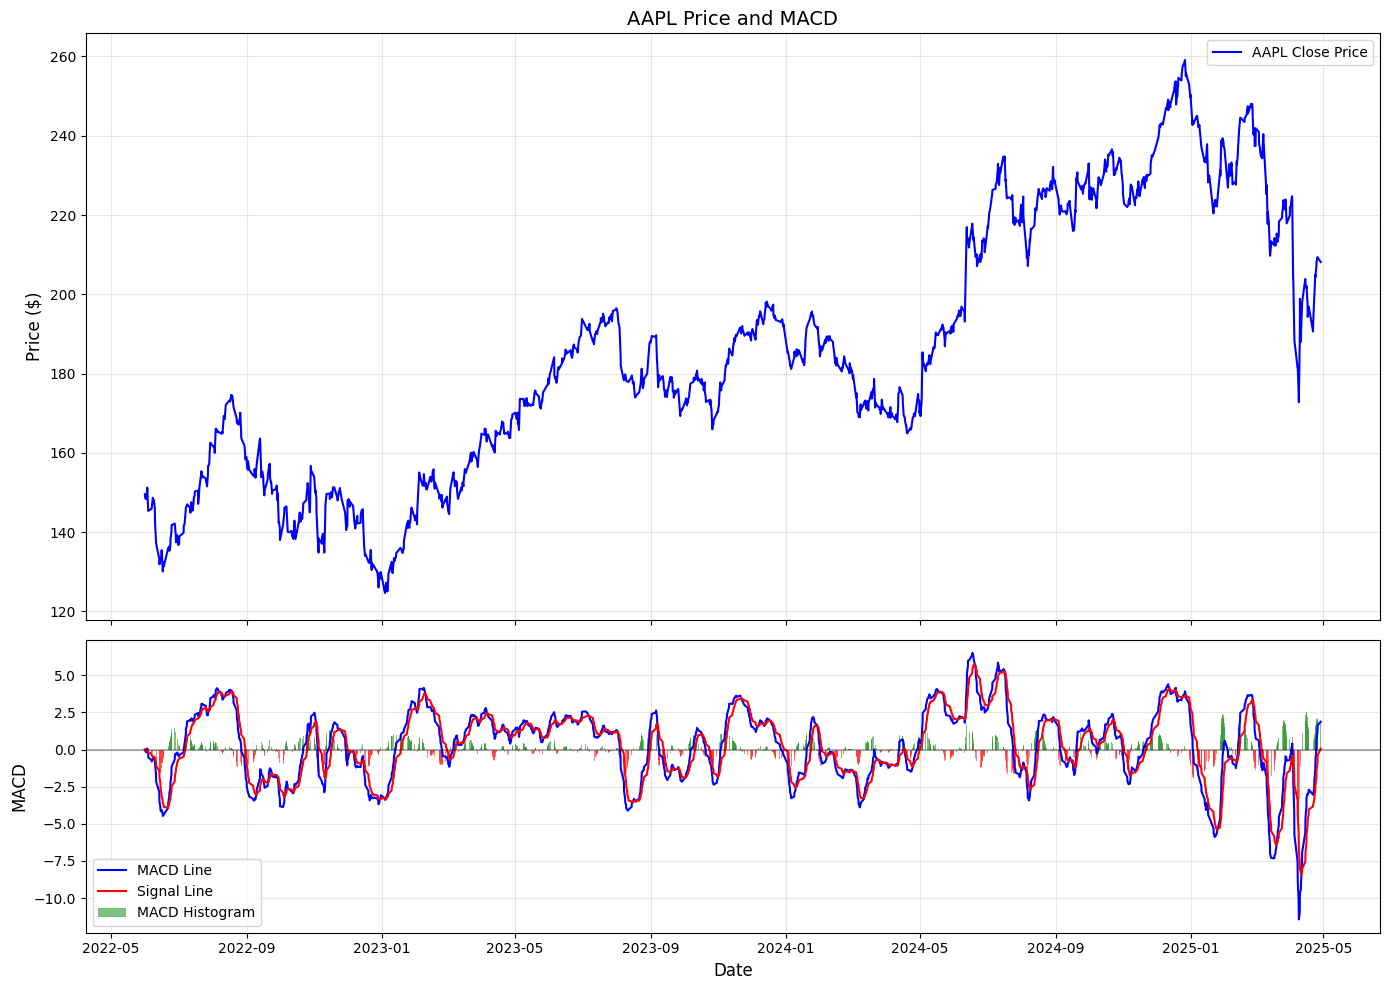

In [467]:
# Create a figure with two subplots (price and MACD)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

# Plot the closing price on the top subplot
ax1.plot(data.index, data['Close'], label='AAPL Close Price', color='blue')
ax1.set_title('AAPL Price and MACD', fontsize=14)
ax1.set_ylabel('Price ($)', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.legend(loc='best')

# Plot the MACD on the bottom subplot
ax2.plot(data.index, data['MACD'], label='MACD Line', color='blue')
ax2.plot(data.index, data['MACD_Signal'], label='Signal Line', color='red')
ax2.bar(data.index, data['MACD_Histo'], label='MACD Histogram', color='green', alpha=0.5, width=0.7)
ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3)
ax2.set_ylabel('MACD', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.legend(loc='best')

# Add colors to histogram based on values (green for positive, red for negative)
for i, val in enumerate(data['MACD_Histo']):
    if i < len(data.index):  # Ensure we don't go out of bounds
        if val >= 0:
            ax2.patches[i].set_facecolor('green')
        else:
            ax2.patches[i].set_facecolor('red')

plt.xlabel('Date', fontsize=12)
plt.tight_layout()
plt.show()

In [468]:
def add_donchian_channels(df: pd.DataFrame, window=20):
  df["DC_Lower"] = df["Low"].rolling(window=window).min()
  df["DC_Upper"] = df["High"].rolling(window=window).max()
  df["DC_Mid"] = (df["High"] + df["Low"]) / 2
  df["DC_Width"] = df["DC_Upper"] - df["DC_Lower"]

  df["DC_Breakout_Strength"] = (df["Close"] - df["DC_Mid"]) / df["DC_Width"]

  return df

data = add_donchian_channels(data)

ValueError: Cannot set a DataFrame with multiple columns to the single column DC_Breakout_Strength

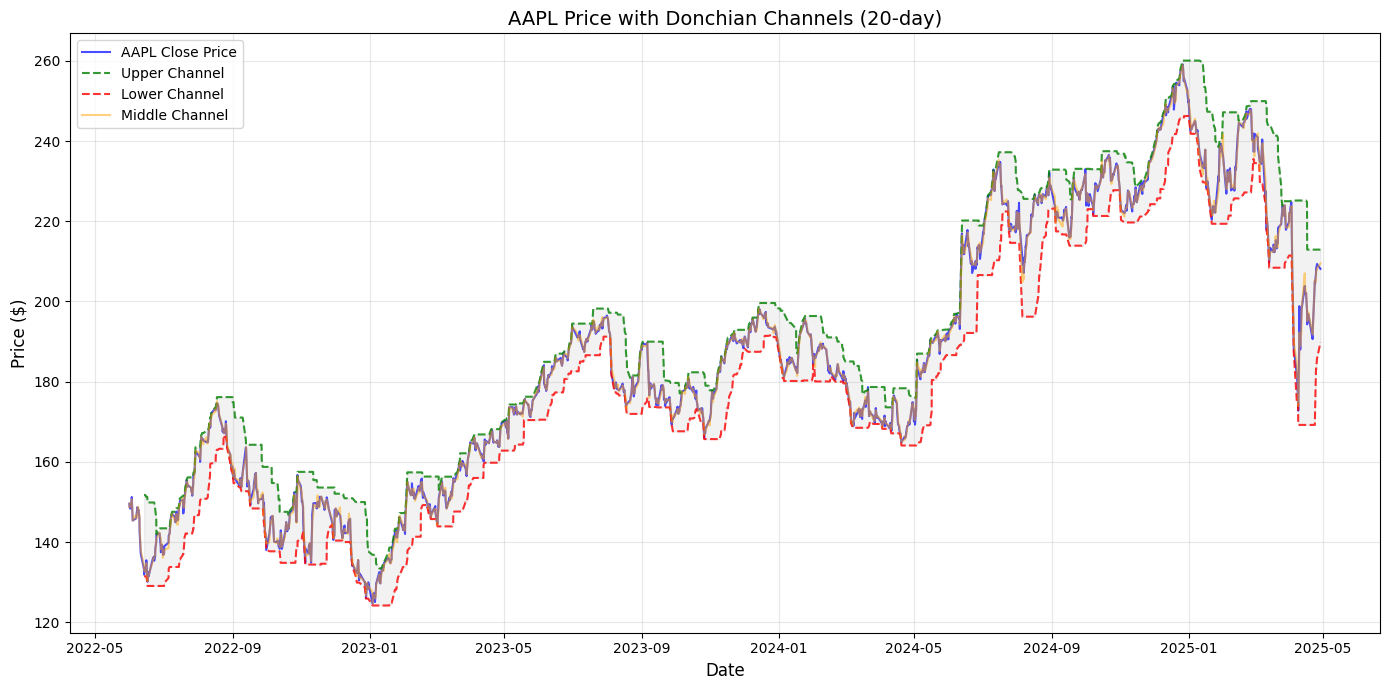

In [ ]:
# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

# Plot the price and Donchian Channels on the top subplot
ax1.plot(data.index, data['Close'], label='AAPL Close Price', color='blue', alpha=0.7)
ax1.plot(data.index, data['DC_Upper'], label='Upper Channel', color='green', linestyle='--', alpha=0.8)
ax1.plot(data.index, data['DC_Lower'], label='Lower Channel', color='red', linestyle='--', alpha=0.8)
ax1.plot(data.index, data['DC_Mid'], label='Middle Channel', color='orange', linestyle='-', alpha=0.5)
ax1.fill_between(data.index, data['DC_Upper'], data['DC_Lower'], color='gray', alpha=0.1)
ax1.set_title('AAPL Price with Donchian Channels (20-day)', fontsize=14)
ax1.set_ylabel('Price ($)', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.legend(loc='best')

# Plot the Breakout Strength on the bottom subplot
ax2.plot(data.index, data['DC_Breakout_Strength'], label='Breakout Strength', color='purple')
ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3)
ax2.axhline(y=0.5, color='green', linestyle='--', alpha=0.5)  # Strong bullish breakout threshold
ax2.axhline(y=-0.5, color='red', linestyle='--', alpha=0.5)   # Strong bearish breakout threshold
ax2.fill_between(data.index, data['DC_Breakout_Strength'], 0, 
                where=(data['DC_Breakout_Strength'] >= 0), 
                color='green', alpha=0.3)
ax2.fill_between(data.index, data['DC_Breakout_Strength'], 0, 
                where=(data['DC_Breakout_Strength'] <= 0), 
                color='red', alpha=0.3)
ax2.set_ylabel('Breakout Strength', fontsize=12)
ax2.set_ylim(-1, 1)  # Set reasonable limits for the indicator
ax2.grid(True, alpha=0.3)
ax2.legend(loc='best')

plt.xlabel('Date', fontsize=12)
plt.tight_layout()
plt.show()